### Analisis y procesamiento de senales

# TS0-*Pedro Joaquin Cannavo*

# **Introduccion**

En este trabajo estudiamos el proceso por el cual una señal analógica puede ser representada de forma digital, mediante la generación de señales senoidales y su posterior muestreo. A partir de esto, buscamos comprender qué implica tomar una señal analógica, que puede tomar valores continuamente a lo largo del tiempo, y obtener muestras de ella en determinados instantes para poder representarla digitalmente.

La cantidad de muestras que se toman por segundo está determinada por la frecuencia de muestreo, la cual definimos como parte de los parámetros de nuestro programa. A lo largo del trabajo veremos la importancia de elegir adecuadamente esta frecuencia de muestreo y su relación con la frecuencia de la señal, utilizando como referencia el Teorema de Muestreo de Nyquist-Shannon.

Además, realizaremos diferentes experimentos modificando la frecuencia de las señales generadas, con el objetivo de observar qué sucede cuando la frecuencia de muestreo no es suficiente. De esta manera, podremos analizar el fenómeno conocido como aliasing y comprender sus efectos sobre la representación digital de una señal.

# **Desarrollo**

En la primera parte del experimento diseñé una función capaz de generar una señal senoidal, la cual está definida por la siguiente expresión:

$$
x(t) = V_{\text{max}}\sin(2\pi f t + \phi) + DC
$$

donde Vmax representa la amplitud máxima de la señal, DC su valor medio o desplazamiento, ff la frecuencia de la señal y ϕ su fase. Además, la función recibe como parámetros la cantidad de muestras N y la frecuencia de muestreo fs, que determinan cómo se representa digitalmente la señal.

Los valores iniciales utilizados para estos parámetros fueron establecidos a partir de la consigna. Para desarrollar la función se utilizaron principalmente las librerías NumPy y Matplotlib, que permiten realizar las operaciones matemáticas necesarias y generar los gráficos de las señales obtenidas.



In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Hago la funcion senoidal

def funcion_seno(vmax, dc, ff, ph, nn, fs):
    
    tt = (np.arange(nn)/fs).reshape(-1, 1)
    
    xx = (vmax * np.sin(2 * np.pi * ff * tt + ph) + dc).reshape(-1, 1)
    
    return tt, xx

#Cantidad de muestras
N=1000

#Frecuencia de muestreo 
fs=1000 

Una vez definida la función, generé y grafiqué una primera señal senoidal, que sirve como referencia para los experimentos posteriores.


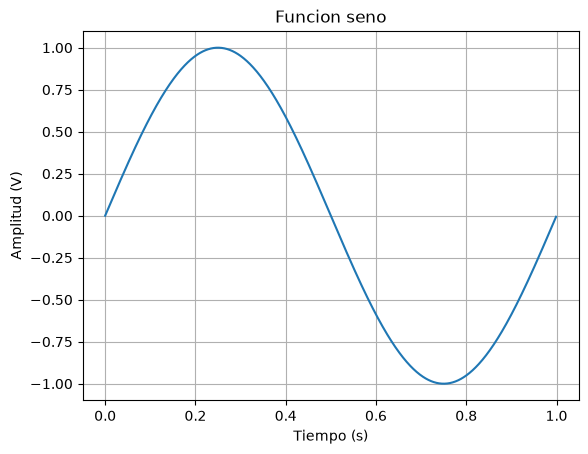

In [5]:
# llamo a la funcion y le doy los datos que quiero
tt, xx = funcion_seno(vmax=1, dc=0, ff=1, ph=0, nn= N, fs = fs)

#Grafico la funcion

plt.figure(1)
plt.plot(tt, xx)
plt.title('Funcion seno')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.show()

Luego definí un vector que contiene las cuatro frecuencias propuestas en la consigna: 500 Hz, 999 Hz, 1001 Hz y 2001 Hz. Mediante un bucle for, cada una de estas frecuencias es enviada como parámetro a la función, permitiendo generar y graficar las cuatro señales sin tener que repetir manualmente el código.

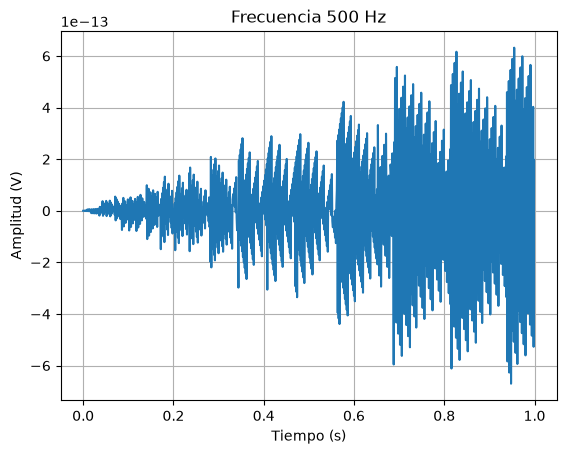

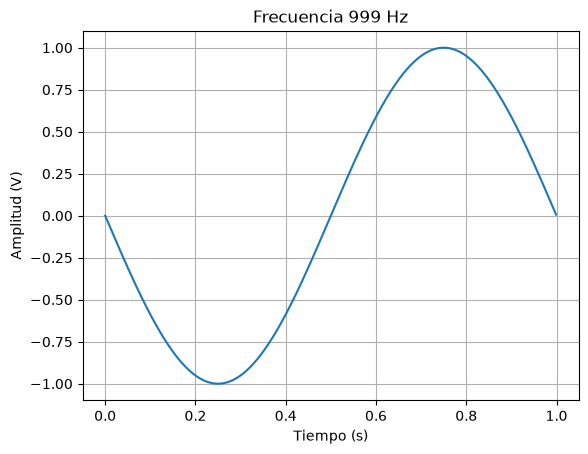

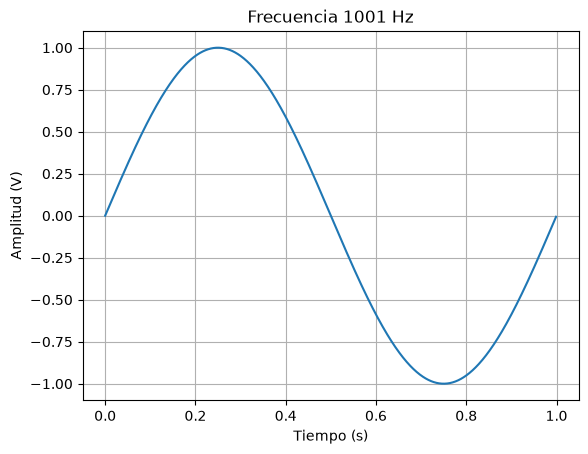

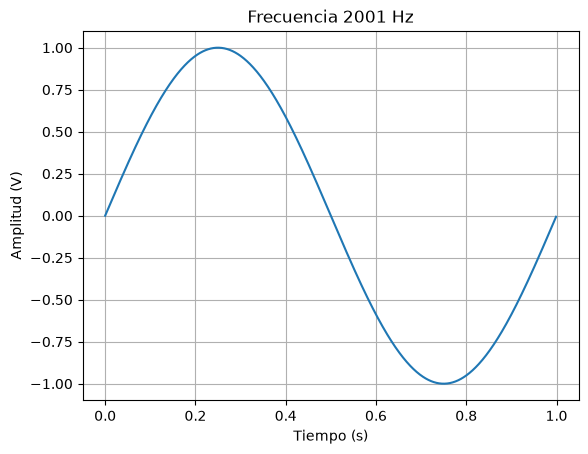

In [6]:
#Ahora quiero hacer un vector para las frecuencias de prueba
Frecuencias= [500, 999, 1001, 2001]

#Y despues hacer un loop para pasarle esos valores de vector a la funcion para que los grafique
i=2#Este lo uso para cambiar el figure number

for frecNow in Frecuencias:
    tt, xx = funcion_seno(vmax=1, dc=0, ff = frecNow, ph=0, nn= N, fs = 1000)
    
    
    plt.figure(i)
    plt.plot(tt, xx)
    plt.title(f"Frecuencia {frecNow} Hz" )
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (V)')
    plt.grid(True)
    plt.show()
    
    i+= 1

Finalmente, agrupé las cuatro señales en un mismo subplot, con el objetivo de poder compararlas visualmente y analizar cómo cambia su representación al variar la frecuencia de la señal manteniendo constante la frecuencia de muestreo.

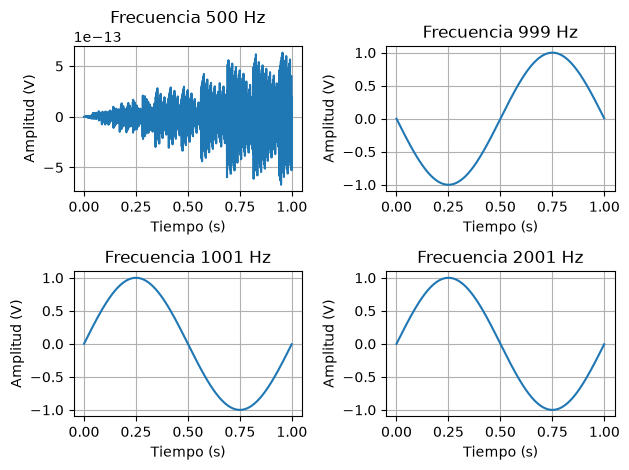

In [7]:
#For para poner los 4 graficos juntos y compararlos    
    
plt.figure(6)

posicion = 1

for frecNow in Frecuencias:
    
    tt, xx = funcion_seno(
        vmax=1,
        dc=0,
        ff=frecNow,
        ph=0,
        nn=N,
        fs=1000
    )
    
    plt.subplot(2, 2, posicion)
    plt.plot(tt, xx)
    plt.title(f"Frecuencia {frecNow} Hz")
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (V)')
    plt.grid(True)
    
    posicion += 1

plt.tight_layout()
plt.show()


## **Conclusion**

A partir de los experimentos realizados pudimos observar el fenómeno del aliasing, viendo en los gráficos qué sucede con la señal cuando estamos en el límite de la frecuencia de Nyquist y cuando nos excedemos de ese valor. Pudimos observar que tener solamente dos muestras por ciclo no es suficiente para representar correctamente una señal, lo que permite entender por qué, para evitar el aliasing, la frecuencia de la señal debe ser menor que la mitad de la frecuencia de muestreo, y no menor o igual.

También pudimos observar qué ocurre con las señales de 999 Hz y 1001 Hz al utilizar una frecuencia de muestreo de 1000 Hz. Aunque ambas señales tienen una frecuencia cercana a la de muestreo, las muestras obtenidas hacen que parezcan señales de una frecuencia mucho menor, aproximadamente 1 Hz. Esto demuestra que cuando no se cumple el criterio de Nyquist, no necesariamente obtenemos una señal que simplemente se vea mal, sino que podemos obtener una señal que parece correcta pero que en realidad representa una frecuencia diferente a la señal original.

En conclusión, el experimento permitió relacionar la frecuencia de la señal con la cantidad de muestras tomadas por ciclo y entender la importancia de utilizar una frecuencia de muestreo suficientemente alta para representar correctamente una señal y evitar la pérdida de información producida por el aliasing.